In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pickle

In [21]:
## load dataset
df = pd.read_csv("credit_card_fraud_dataset.csv")
df.head(10)



,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
5,6,2024-08-30 01:52:35.462867,3086.22,302,purchase,New York,0
6,7,2024-01-02 11:31:35.462875,1466.90,902,refund,Philadelphia,0
7,8,2024-05-12 12:25:35.462885,917.21,266,purchase,New York,0
8,9,2023-11-16 02:20:35.462894,1625.73,32,refund,Chicago,0
9,10,2023-10-24 06:51:35.462901,662.07,193,purchase,Dallas,0


In [22]:
print(df.shape)

(100000, 7)


In [23]:
## checking data
df.describe()


,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


In [24]:
print(df['IsFraud'].value_counts())

## 0 > Normal  1 > Fraud

IsFraud
0    99000
1     1000
Name: count, dtype: int64


In [25]:
print(df.columns)

Index(['TransactionID', 'TransactionDate', 'Amount', 'MerchantID',
       'TransactionType', 'Location', 'IsFraud'],
      dtype='object')


### Data cleaning and Pre processing



In [26]:
## remove id  because id is unique - no pattern and also useless for prediction

df = df.drop(['TransactionID'],axis=1)


In [11]:
df.tail(100)

,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
99900,2024-02-19 07:13:36.027237,3790.17,403,refund,San Jose,0
99901,2023-11-22 14:25:36.027241,229.18,702,purchase,New York,0
99902,2024-07-11 16:45:36.027244,2509.73,37,purchase,Dallas,0
99903,2024-01-13 13:11:36.027247,4903.16,804,refund,Philadelphia,0
99904,2024-01-04 18:17:36.027251,4999.02,873,refund,Houston,0
...,...,...,...,...,...,...
99995,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [27]:
## ML cannot understand full date but time pattern matters like late night might be suspicious .... day helps detect patterns like end of month fraud may occur

# Convert column to datetime format
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

df['hour'] = df['TransactionDate'].dt.hour
df['day'] = df['TransactionDate'].dt.day

df = df.drop(['TransactionDate'], axis=1)

In [28]:
df.head()

,Amount,MerchantID,TransactionType,Location,IsFraud,hour,day
0,4189.27,688,refund,San Antonio,0,14,3
1,2659.71,109,refund,Dallas,0,13,19
2,784.00,394,purchase,New York,0,10,8
3,3514.40,944,purchase,Philadelphia,0,23,13
4,369.07,475,purchase,Phoenix,0,18,12


In [29]:
## one hot encoding

## Converts categorical text data into 0 or 1

df = pd.get_dummies(df,columns=['TransactionType','Location'],drop_first=True)

In [30]:
## X = input features
## y = answer (fraud or not)
X = df.drop('IsFraud', axis=1)
y = df['IsFraud']

In [16]:
df.head()

,Amount,MerchantID,TransactionType,Location,IsFraud,hour,day
0,4189.27,688,refund,San Antonio,0,14,3
1,2659.71,109,refund,Dallas,0,13,19
2,784.00,394,purchase,New York,0,10,8
3,3514.40,944,purchase,Philadelphia,0,23,13
4,369.07,475,purchase,Phoenix,0,18,12


### EDA (Exploratory Data Analysis)

In [31]:
## check  missing values in each column
print(df.isnull().sum())


Amount                    0
MerchantID                0
IsFraud                   0
hour                      0
day                       0
TransactionType_refund    0
Location_Dallas           0
Location_Houston          0
Location_Los Angeles      0
Location_New York         0
Location_Philadelphia     0
Location_Phoenix          0
Location_San Antonio      0
Location_San Diego        0
Location_San Jose         0
dtype: int64


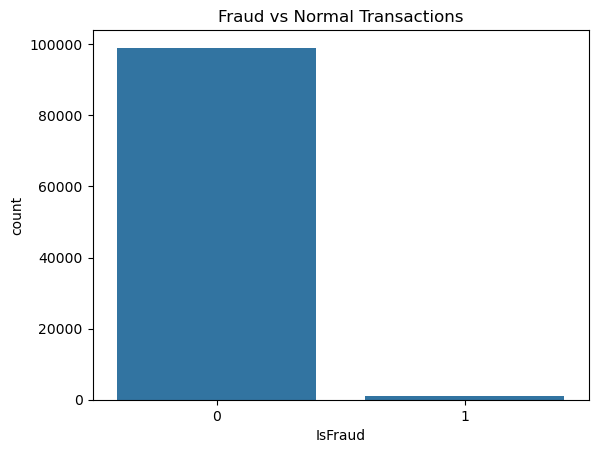

In [ ]:
# visualization
sns.countplot(x='IsFraud', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [34]:
# Fraud percentage
fraud_percentage = df['IsFraud'].value_counts(normalize=True) * 100
print(fraud_percentage)

IsFraud
0    99.0
1     1.0
Name: proportion, dtype: float64


### Train Test split


In [36]:
# Train data - teaches model
# Test data - checks performance
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2)


print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)
print("y_train shape: ",y_train.shape)
print("y_test shape: ",y_test.shape)

X_train shape:  (80000, 14)
X_test shape:  (20000, 14)
y_train shape:  (80000,)
y_test shape:  (20000,)


### Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

# Pattern > Fraud
# Pattern > Not Fraud

LogisticRegression()